In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


import pandas as pd
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view

import matplotlib.pyplot as plt

Epoch 1/10,Training Loss: 0.1975
Epoch 2/10,Training Loss: 0.1700
Epoch 3/10,Training Loss: 0.1658
Epoch 4/10,Training Loss: 0.1586
Epoch 5/10,Training Loss: 0.1544
Epoch 6/10,Training Loss: 0.1521
Epoch 7/10,Training Loss: 0.1507
Epoch 8/10,Training Loss: 0.1496
Epoch 9/10,Training Loss: 0.1488
Epoch 10/10,Training Loss: 0.1482
Test Loss: 0.1873
Actual up: 526, Predicted up: 909
Accuracy: 0.541


Text(0.5, 1.0, 'actual')

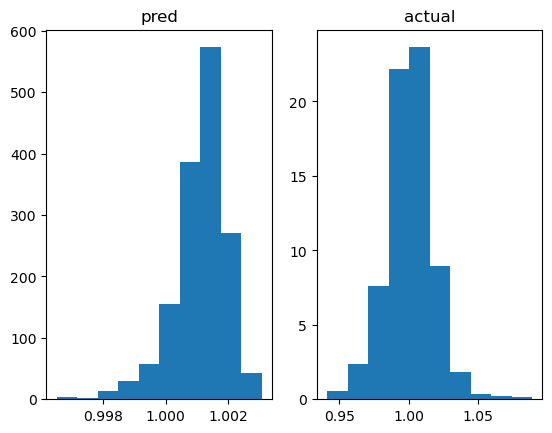

In [21]:
#bazowa wersja modelu

#wczytuję ceny akcji
df = pd.read_csv("AAPL.csv")
close = np.array(df["Close"])


#wyznaczam zwroty logarytmiczne
returns = close[1:]/close[:-1]
log_returns = np.log(returns)

#wyznaczam kroczące volatility
rvolwin  = 10
windows = sliding_window_view(log_returns, window_shape=rvolwin)
rvol = windows.std(axis=1, ddof=1)

#odpowiedio skracam zwroty aby odpowiaday kroczącemu volatility
log_returns = log_returns[rvolwin-1:]

#sklejam zwroty i kroczące volatility
combined = np.vstack((rvol, 
              log_returns))

#wyznaczam parametry do standaryzacji danych 
rvol_sd = np.std(rvol)
rvol_mean = np.mean(rvol)

log_returns_sd = np.std(log_returns)
log_returns_mean = np.mean(log_returns)

#standaryzuje dane
combined[0,:] =  (combined[0,:] - rvol_mean)/rvol_sd
combined[1,:] =  (combined[1,:] - log_returns_mean)/log_returns_sd

#tworzę ciągi długości seq len, na ktorych będę uczył model
seq_len = 5

X = []
Y = []

for i in range(combined.shape[1] - seq_len):
    X.append(combined[:,i:(seq_len + i)])
    Y.append(combined[:,i + seq_len])

#formatuję dane 

X = torch.tensor(X).float()
Y = torch.tensor(Y).float()

X = X.reshape((X.shape[0],
               X.shape[2],
               X.shape[1]))

#dzielę na podzbiór uczący i testowy
test_size = 1000

test_X = X[X.shape[0]- test_size:, :, :]
test_Y = Y[Y.shape[0] - test_size:,]

train_X = X[:-test_size, :, :]
train_Y = Y[:-test_size,:]

class model(nn.Module):
    #inicjalizaja modelu
    def __init__(self, input_size=2, hidden_size=50, output_size=2):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=False)
        self.fc = nn.Linear(hidden_size, output_size)

    #propagacja w przód
    def forward(self, x):
        x = x.transpose(0, 1)
        out, _ = self.rnn(x)
        out = self.fc(out[-1]) 
        return out

#obiekty do wczytywania danych

train_dataset = TensorDataset(train_X, train_Y)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

test_dataset = TensorDataset(test_X, test_Y)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

#inijalizacja modelu
model = model()
#kryterium
criterion = nn.MSELoss()
#algorytm optymalizacji
optimizer = torch.optim.Adam(model.parameters(), lr= 0.0001)

#pętla ucząca
num_epochs = 10
for epoch in range(num_epochs):
    #trub uczący 
    model.train()
    for batch_x, batch_y in train_loader:
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        optimizer.zero_grad()
        loss.backward()
        #zapobiega eksplozji gradientu 
        optimizer.step()
    print(f"Epoch {epoch+1}/{num_epochs},Training Loss: {loss.item():.4f}")

#tryb predykcji 
model.eval()
test_loss = 0
#obliczanie błędu predykcji 
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        test_loss += criterion(outputs, batch_y).item()
test_loss /= len(test_loader)
print(f"Test Loss: {test_loss:.4f}")

pred = (model(test_X).T[1,:]*log_returns_sd + log_returns_mean).exp()
actual = np.exp(log_returns[len(log_returns) - test_size:])

print(f"Actual up: {sum(actual > 1)}, Predicted up: {sum(pred>1)}")

val = ((pd.DataFrame(actual > 1) == pd.DataFrame(pred > 1)).sum()/test_size)[0]
print(f"Accuracy: {val}")
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

plt.subplot(1, 2, 1)
plt.hist(pred.detach().numpy(), density = True)
plt.title("pred")
plt.subplot(1, 2, 2)
plt.hist(actual, density = True)
plt.title("actual")




Epoch 1/10,Training Loss: 0.1635
Epoch 2/10,Training Loss: 0.1676
Epoch 3/10,Training Loss: 0.1564
Epoch 4/10,Training Loss: 0.1510
Epoch 5/10,Training Loss: 0.1494
Epoch 6/10,Training Loss: 0.1488
Epoch 7/10,Training Loss: 0.1484
Epoch 8/10,Training Loss: 0.1481
Epoch 9/10,Training Loss: 0.1479
Epoch 10/10,Training Loss: 0.1477
Test Loss: 0.1869
Actual up: 526, Predicted up: 914
Accuracy: 0.532


Text(0.5, 1.0, 'actual')

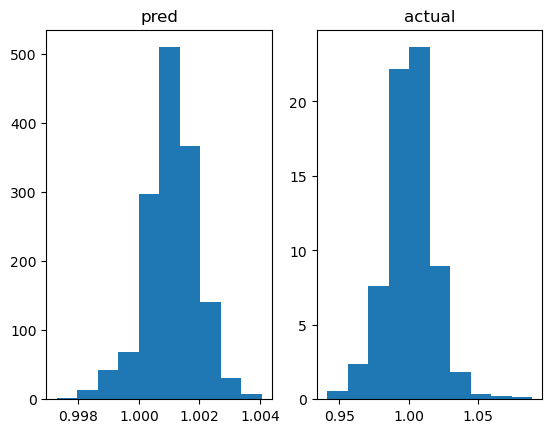

In [30]:
#gradient clipping

#wczytuję ceny akcji
df = pd.read_csv("AAPL.csv")
close = np.array(df["Close"])


#wyznaczam zwroty logarytmiczne
returns = close[1:]/close[:-1]
log_returns = np.log(returns)

#wyznaczam kroczące volatility
rvolwin  = 10
windows = sliding_window_view(log_returns, window_shape=rvolwin)
rvol = windows.std(axis=1, ddof=1)

#odpowiedio skracam zwroty aby odpowiaday kroczącemu volatility
log_returns = log_returns[rvolwin-1:]

#sklejam zwroty i kroczące volatility
combined = np.vstack((rvol, 
              log_returns))

#wyznaczam parametry do standaryzacji danych 
rvol_sd = np.std(rvol)
rvol_mean = np.mean(rvol)

log_returns_sd = np.std(log_returns)
log_returns_mean = np.mean(log_returns)

#standaryzuje dane
combined[0,:] =  (combined[0,:] - rvol_mean)/rvol_sd
combined[1,:] =  (combined[1,:] - log_returns_mean)/log_returns_sd

#tworzę ciągi długości seq len, na ktorych będę uczył model
seq_len = 5

X = []
Y = []

for i in range(combined.shape[1] - seq_len):
    X.append(combined[:,i:(seq_len + i)])
    Y.append(combined[:,i + seq_len])

#formatuję dane 

X = torch.tensor(X).float()
Y = torch.tensor(Y).float()

X = X.reshape((X.shape[0],
               X.shape[2],
               X.shape[1]))

#dzielę na podzbiór uczący i testowy
test_size = 1000

test_X = X[X.shape[0]- test_size:, :, :]
test_Y = Y[Y.shape[0] - test_size:,]

train_X = X[:-test_size, :, :]
train_Y = Y[:-test_size,:]

class model(nn.Module):
    #inicjalizaja modelu
    def __init__(self, input_size=2, hidden_size=50, output_size=2):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=False)
        self.fc = nn.Linear(hidden_size, output_size)

    #propagacja w przód
    def forward(self, x):
        x = x.transpose(0, 1)
        out, _ = self.rnn(x)
        out = self.fc(out[-1]) 
        return out

#obiekty do wczytywania danych

train_dataset = TensorDataset(train_X, train_Y)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

test_dataset = TensorDataset(test_X, test_Y)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

#inijalizacja modelu
model = model()
#kryterium
criterion = nn.MSELoss()
#algorytm optymalizacji
optimizer = torch.optim.Adam(model.parameters(), lr= 0.0001)

#pętla ucząca
num_epochs = 10
for epoch in range(num_epochs):
    #trub uczący 
    model.train()
    for batch_x, batch_y in train_loader:
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        optimizer.zero_grad()
        loss.backward()
        #zapobiega eksplozji gradientu 
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
    print(f"Epoch {epoch+1}/{num_epochs},Training Loss: {loss.item():.4f}")

#tryb predykcji 
model.eval()
test_loss = 0
#obliczanie błędu predykcji 
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        test_loss += criterion(outputs, batch_y).item()
test_loss /= len(test_loader)
print(f"Test Loss: {test_loss:.4f}")

pred = (model(test_X).T[1,:]*log_returns_sd + log_returns_mean).exp()
actual = np.exp(log_returns[len(log_returns) - test_size:])

print(f"Actual up: {sum(actual > 1)}, Predicted up: {sum(pred>1)}")

val = ((pd.DataFrame(actual > 1) == pd.DataFrame(pred > 1)).sum()/test_size)[0]
print(f"Accuracy: {val}")
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

plt.subplot(1, 2, 1)
plt.hist(pred.detach().numpy(), density = True)
plt.title("pred")
plt.subplot(1, 2, 2)
plt.hist(actual, density = True)
plt.title("actual")




Epoch 1/10,Training Loss: 0.1662
Epoch 2/10,Training Loss: 0.1495
Epoch 3/10,Training Loss: 0.1472
Epoch 4/10,Training Loss: 0.1465
Epoch 5/10,Training Loss: 0.1459
Epoch 6/10,Training Loss: 0.1454
Epoch 7/10,Training Loss: 0.1451
Epoch 8/10,Training Loss: 0.1448
Epoch 9/10,Training Loss: 0.1446
Epoch 10/10,Training Loss: 0.1445
Test Loss: 0.1863
Actual up: 526, Predicted up: 907
Accuracy: 0.533


Text(0.5, 1.0, 'actual')

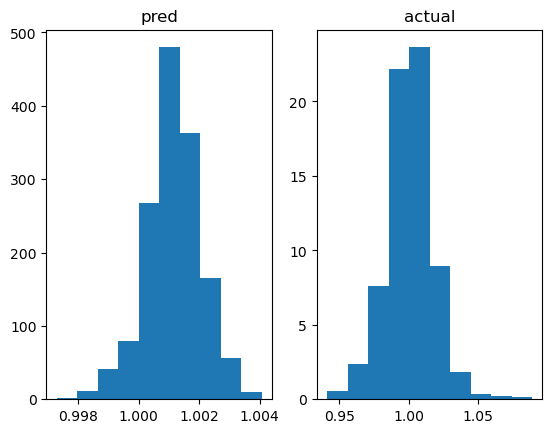

In [31]:
#większe warstwy rekurencyjne

#wczytuję ceny akcji
df = pd.read_csv("AAPL.csv")
close = np.array(df["Close"])


#wyznaczam zwroty logarytmiczne
returns = close[1:]/close[:-1]
log_returns = np.log(returns)

#wyznaczam kroczące volatility
rvolwin  = 10
windows = sliding_window_view(log_returns, window_shape=rvolwin)
rvol = windows.std(axis=1, ddof=1)

#odpowiedio skracam zwroty aby odpowiaday kroczącemu volatility
log_returns = log_returns[rvolwin-1:]

#sklejam zwroty i kroczące volatility
combined = np.vstack((rvol, 
              log_returns))

#wyznaczam parametry do standaryzacji danych 
rvol_sd = np.std(rvol)
rvol_mean = np.mean(rvol)

log_returns_sd = np.std(log_returns)
log_returns_mean = np.mean(log_returns)

#standaryzuje dane
combined[0,:] =  (combined[0,:] - rvol_mean)/rvol_sd
combined[1,:] =  (combined[1,:] - log_returns_mean)/log_returns_sd

#tworzę ciągi długości seq len, na ktorych będę uczył model
seq_len = 5

X = []
Y = []

for i in range(combined.shape[1] - seq_len):
    X.append(combined[:,i:(seq_len + i)])
    Y.append(combined[:,i + seq_len])

#formatuję dane 

X = torch.tensor(X).float()
Y = torch.tensor(Y).float()

X = X.reshape((X.shape[0],
               X.shape[2],
               X.shape[1]))

#dzielę na podzbiór uczący i testowy
test_size = 1000

test_X = X[X.shape[0]- test_size:, :, :]
test_Y = Y[Y.shape[0] - test_size:,]

train_X = X[:-test_size, :, :]
train_Y = Y[:-test_size,:]

class model(nn.Module):
    #inicjalizaja modelu
    def __init__(self, input_size=2, hidden_size=100, output_size=2):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=False)
        self.fc = nn.Linear(hidden_size, output_size)

    #propagacja w przód
    def forward(self, x):
        x = x.transpose(0, 1)
        out, _ = self.rnn(x)
        out = self.fc(out[-1]) 
        return out

#obiekty do wczytywania danych

train_dataset = TensorDataset(train_X, train_Y)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

test_dataset = TensorDataset(test_X, test_Y)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

#inijalizacja modelu
model = model()
#kryterium
criterion = nn.MSELoss()
#algorytm optymalizacji
optimizer = torch.optim.Adam(model.parameters(), lr= 0.0001)

#pętla ucząca
num_epochs = 10
for epoch in range(num_epochs):
    #trub uczący 
    model.train()
    for batch_x, batch_y in train_loader:
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        optimizer.zero_grad()
        loss.backward()
        #zapobiega eksplozji gradientu 
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
    print(f"Epoch {epoch+1}/{num_epochs},Training Loss: {loss.item():.4f}")

#tryb predykcji 
model.eval()
test_loss = 0
#obliczanie błędu predykcji 
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        test_loss += criterion(outputs, batch_y).item()
test_loss /= len(test_loader)
print(f"Test Loss: {test_loss:.4f}")

pred = (model(test_X).T[1,:]*log_returns_sd + log_returns_mean).exp()
actual = np.exp(log_returns[len(log_returns) - test_size:])

print(f"Actual up: {sum(actual > 1)}, Predicted up: {sum(pred>1)}")

val = ((pd.DataFrame(actual > 1) == pd.DataFrame(pred > 1)).sum()/test_size)[0]
print(f"Accuracy: {val}")
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

plt.subplot(1, 2, 1)
plt.hist(pred.detach().numpy(), density = True)
plt.title("pred")
plt.subplot(1, 2, 2)
plt.hist(actual, density = True)
plt.title("actual")




Epoch 1/10,Training Loss: 0.1105
Epoch 2/10,Training Loss: 0.1371
Epoch 3/10,Training Loss: 0.1182
Epoch 4/10,Training Loss: 0.1308
Epoch 5/10,Training Loss: 0.1191
Epoch 6/10,Training Loss: 0.1138
Epoch 7/10,Training Loss: 0.1243
Epoch 8/10,Training Loss: 0.1356
Epoch 9/10,Training Loss: 0.1394
Epoch 10/10,Training Loss: 0.1325
Test Loss: 0.2050
Actual up: 526, Predicted up: 882
Accuracy: 0.526


Text(0.5, 1.0, 'actual')

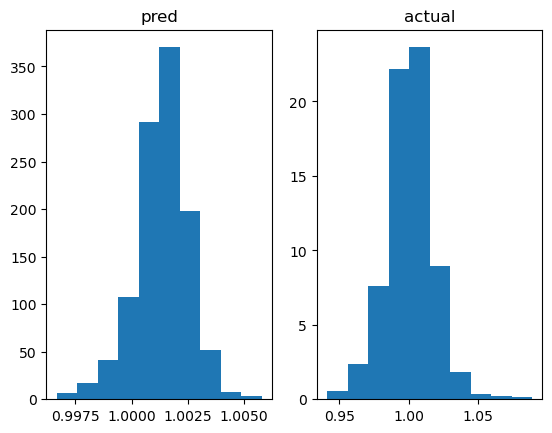

In [32]:
#dłuższe ciągi

#wczytuję ceny akcji
df = pd.read_csv("AAPL.csv")
close = np.array(df["Close"])


#wyznaczam zwroty logarytmiczne
returns = close[1:]/close[:-1]
log_returns = np.log(returns)

#wyznaczam kroczące volatility
rvolwin  = 10
windows = sliding_window_view(log_returns, window_shape=rvolwin)
rvol = windows.std(axis=1, ddof=1)

#odpowiedio skracam zwroty aby odpowiaday kroczącemu volatility
log_returns = log_returns[rvolwin-1:]

#sklejam zwroty i kroczące volatility
combined = np.vstack((rvol, 
              log_returns))

#wyznaczam parametry do standaryzacji danych 
rvol_sd = np.std(rvol)
rvol_mean = np.mean(rvol)

log_returns_sd = np.std(log_returns)
log_returns_mean = np.mean(log_returns)

#standaryzuje dane
combined[0,:] =  (combined[0,:] - rvol_mean)/rvol_sd
combined[1,:] =  (combined[1,:] - log_returns_mean)/log_returns_sd

#tworzę ciągi długości seq len, na ktorych będę uczył model
seq_len = 20

X = []
Y = []

for i in range(combined.shape[1] - seq_len):
    X.append(combined[:,i:(seq_len + i)])
    Y.append(combined[:,i + seq_len])

#formatuję dane 

X = torch.tensor(X).float()
Y = torch.tensor(Y).float()

X = X.reshape((X.shape[0],
               X.shape[2],
               X.shape[1]))

#dzielę na podzbiór uczący i testowy
test_size = 1000

test_X = X[X.shape[0]- test_size:, :, :]
test_Y = Y[Y.shape[0] - test_size:,]

train_X = X[:-test_size, :, :]
train_Y = Y[:-test_size,:]

class model(nn.Module):
    #inicjalizaja modelu
    def __init__(self, input_size=2, hidden_size=100, output_size=2):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=False)
        self.fc = nn.Linear(hidden_size, output_size)

    #propagacja w przód
    def forward(self, x):
        x = x.transpose(0, 1)
        out, _ = self.rnn(x)
        out = self.fc(out[-1]) 
        return out

#obiekty do wczytywania danych

train_dataset = TensorDataset(train_X, train_Y)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

test_dataset = TensorDataset(test_X, test_Y)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

#inijalizacja modelu
model = model()
#kryterium
criterion = nn.MSELoss()
#algorytm optymalizacji
optimizer = torch.optim.Adam(model.parameters(), lr= 0.0001)

#pętla ucząca
num_epochs = 10
for epoch in range(num_epochs):
    #trub uczący 
    model.train()
    for batch_x, batch_y in train_loader:
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        optimizer.zero_grad()
        loss.backward()
        #zapobiega eksplozji gradientu 
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
    print(f"Epoch {epoch+1}/{num_epochs},Training Loss: {loss.item():.4f}")

#tryb predykcji 
model.eval()
test_loss = 0
#obliczanie błędu predykcji 
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        test_loss += criterion(outputs, batch_y).item()
test_loss /= len(test_loader)
print(f"Test Loss: {test_loss:.4f}")

pred = (model(test_X).T[1,:]*log_returns_sd + log_returns_mean).exp()
actual = np.exp(log_returns[len(log_returns) - test_size:])

print(f"Actual up: {sum(actual > 1)}, Predicted up: {sum(pred>1)}")

val = ((pd.DataFrame(actual > 1) == pd.DataFrame(pred > 1)).sum()/test_size)[0]
print(f"Accuracy: {val}")
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

plt.subplot(1, 2, 1)
plt.hist(pred.detach().numpy(), density = True)
plt.title("pred")
plt.subplot(1, 2, 2)
plt.hist(actual, density = True)
plt.title("actual")




C:\Users\igorm\AppData\Roaming\Python\Python311\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.4 and num_layers=1
  warnings.warn(


Epoch 1/10,Training Loss: 0.1160
Epoch 2/10,Training Loss: 0.1208
Epoch 3/10,Training Loss: 0.1188
Epoch 4/10,Training Loss: 0.1168
Epoch 5/10,Training Loss: 0.1087
Epoch 6/10,Training Loss: 0.1192
Epoch 7/10,Training Loss: 0.1291
Epoch 8/10,Training Loss: 0.1340
Epoch 9/10,Training Loss: 0.1385
Epoch 10/10,Training Loss: 0.1394
Test Loss: 0.2092
Actual up: 526, Predicted up: 898
Accuracy: 0.532


Text(0.5, 1.0, 'actual')

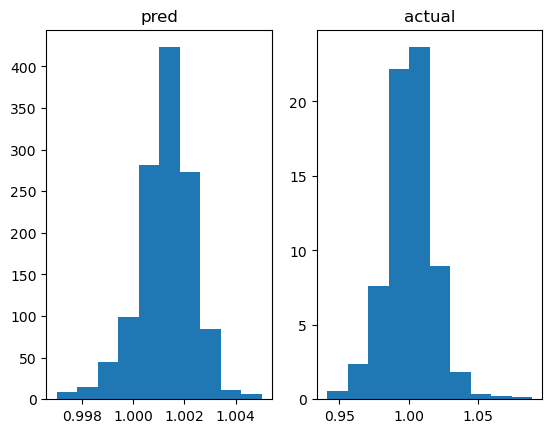

In [33]:
#dropout

#wczytuję ceny akcji
df = pd.read_csv("AAPL.csv")
close = np.array(df["Close"])


#wyznaczam zwroty logarytmiczne
returns = close[1:]/close[:-1]
log_returns = np.log(returns)

#wyznaczam kroczące volatility
rvolwin  = 10
windows = sliding_window_view(log_returns, window_shape=rvolwin)
rvol = windows.std(axis=1, ddof=1)

#odpowiedio skracam zwroty aby odpowiaday kroczącemu volatility
log_returns = log_returns[rvolwin-1:]

#sklejam zwroty i kroczące volatility
combined = np.vstack((rvol, 
              log_returns))

#wyznaczam parametry do standaryzacji danych 
rvol_sd = np.std(rvol)
rvol_mean = np.mean(rvol)

log_returns_sd = np.std(log_returns)
log_returns_mean = np.mean(log_returns)

#standaryzuje dane
combined[0,:] =  (combined[0,:] - rvol_mean)/rvol_sd
combined[1,:] =  (combined[1,:] - log_returns_mean)/log_returns_sd

#tworzę ciągi długości seq len, na ktorych będę uczył model
seq_len = 20

X = []
Y = []

for i in range(combined.shape[1] - seq_len):
    X.append(combined[:,i:(seq_len + i)])
    Y.append(combined[:,i + seq_len])

#formatuję dane 

X = torch.tensor(X).float()
Y = torch.tensor(Y).float()

X = X.reshape((X.shape[0],
               X.shape[2],
               X.shape[1]))

#dzielę na podzbiór uczący i testowy
test_size = 1000

test_X = X[X.shape[0]- test_size:, :, :]
test_Y = Y[Y.shape[0] - test_size:,]

train_X = X[:-test_size, :, :]
train_Y = Y[:-test_size,:]

class model(nn.Module):
    #inicjalizaja modelu
    def __init__(self, input_size=2, hidden_size=100, output_size=2):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=False, dropout= 0.4)
        self.fc = nn.Linear(hidden_size, output_size)

    #propagacja w przód
    def forward(self, x):
        x = x.transpose(0, 1)
        out, _ = self.rnn(x)
        out = self.fc(out[-1]) 
        return out

#obiekty do wczytywania danych

train_dataset = TensorDataset(train_X, train_Y)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

test_dataset = TensorDataset(test_X, test_Y)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

#inijalizacja modelu
model = model()
#kryterium
criterion = nn.MSELoss()
#algorytm optymalizacji
optimizer = torch.optim.Adam(model.parameters(), lr= 0.0001)

#pętla ucząca
num_epochs = 10
for epoch in range(num_epochs):
    #trub uczący 
    model.train()
    for batch_x, batch_y in train_loader:
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        optimizer.zero_grad()
        loss.backward()
        #zapobiega eksplozji gradientu 
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
    print(f"Epoch {epoch+1}/{num_epochs},Training Loss: {loss.item():.4f}")

#tryb predykcji 
model.eval()
test_loss = 0
#obliczanie błędu predykcji 
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        test_loss += criterion(outputs, batch_y).item()
test_loss /= len(test_loader)
print(f"Test Loss: {test_loss:.4f}")

pred = (model(test_X).T[1,:]*log_returns_sd + log_returns_mean).exp()
actual = np.exp(log_returns[len(log_returns) - test_size:])

print(f"Actual up: {sum(actual > 1)}, Predicted up: {sum(pred>1)}")

val = ((pd.DataFrame(actual > 1) == pd.DataFrame(pred > 1)).sum()/test_size)[0]
print(f"Accuracy: {val}")
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

plt.subplot(1, 2, 1)
plt.hist(pred.detach().numpy(), density = True)
plt.title("pred")
plt.subplot(1, 2, 2)
plt.hist(actual, density = True)
plt.title("actual")




Epoch 1/10,Training Loss: 0.1259
Epoch 2/10,Training Loss: 0.1128
Epoch 3/10,Training Loss: 0.1203
Epoch 4/10,Training Loss: 0.1277
Epoch 5/10,Training Loss: 0.1196
Epoch 6/10,Training Loss: 0.1052
Epoch 7/10,Training Loss: 0.1172
Epoch 8/10,Training Loss: 0.1068
Epoch 9/10,Training Loss: 0.1230
Epoch 10/10,Training Loss: 0.1213
Test Loss: 0.1876
Actual up: 526, Predicted up: 896
Accuracy: 0.518


Text(0.5, 1.0, 'actual')

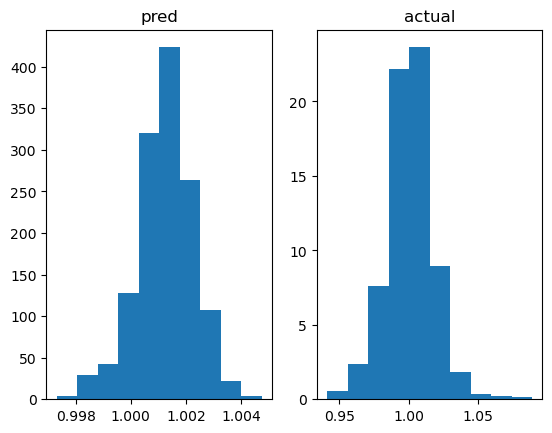

In [34]:

#więcej warstw

#wczytuję ceny akcji
df = pd.read_csv("AAPL.csv")
close = np.array(df["Close"])


#wyznaczam zwroty logarytmiczne
returns = close[1:]/close[:-1]
log_returns = np.log(returns)

#wyznaczam kroczące volatility
rvolwin  = 10
windows = sliding_window_view(log_returns, window_shape=rvolwin)
rvol = windows.std(axis=1, ddof=1)

#odpowiedio skracam zwroty aby odpowiaday kroczącemu volatility
log_returns = log_returns[rvolwin-1:]

#sklejam zwroty i kroczące volatility
combined = np.vstack((rvol, 
              log_returns))

#wyznaczam parametry do standaryzacji danych 
rvol_sd = np.std(rvol)
rvol_mean = np.mean(rvol)

log_returns_sd = np.std(log_returns)
log_returns_mean = np.mean(log_returns)

#standaryzuje dane
combined[0,:] =  (combined[0,:] - rvol_mean)/rvol_sd
combined[1,:] =  (combined[1,:] - log_returns_mean)/log_returns_sd

#tworzę ciągi długości seq len, na ktorych będę uczył model
seq_len = 20

X = []
Y = []

for i in range(combined.shape[1] - seq_len):
    X.append(combined[:,i:(seq_len + i)])
    Y.append(combined[:,i + seq_len])

#formatuję dane 

X = torch.tensor(X).float()
Y = torch.tensor(Y).float()

X = X.reshape((X.shape[0],
               X.shape[2],
               X.shape[1]))

#dzielę na podzbiór uczący i testowy
test_size = 1000

test_X = X[X.shape[0]- test_size:, :, :]
test_Y = Y[Y.shape[0] - test_size:,]

train_X = X[:-test_size, :, :]
train_Y = Y[:-test_size,:]

class model(nn.Module):
    #inicjalizaja modelu
    def __init__(self, input_size=2, hidden_size=100, output_size=2):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=False, dropout= 0.4, num_layers=2)
        self.fc = nn.Linear(hidden_size, output_size)

    #propagacja w przód
    def forward(self, x):
        x = x.transpose(0, 1)
        out, _ = self.rnn(x)
        out = self.fc(out[-1]) 
        return out

#obiekty do wczytywania danych

train_dataset = TensorDataset(train_X, train_Y)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

test_dataset = TensorDataset(test_X, test_Y)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

#inijalizacja modelu
model = model()
#kryterium
criterion = nn.MSELoss()
#algorytm optymalizacji
optimizer = torch.optim.Adam(model.parameters(), lr= 0.0001)

#pętla ucząca
num_epochs = 10
for epoch in range(num_epochs):
    #trub uczący 
    model.train()
    for batch_x, batch_y in train_loader:
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        optimizer.zero_grad()
        loss.backward()
        #zapobiega eksplozji gradientu 
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
    print(f"Epoch {epoch+1}/{num_epochs},Training Loss: {loss.item():.4f}")

#tryb predykcji 
model.eval()
test_loss = 0
#obliczanie błędu predykcji 
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        test_loss += criterion(outputs, batch_y).item()
test_loss /= len(test_loader)
print(f"Test Loss: {test_loss:.4f}")

pred = (model(test_X).T[1,:]*log_returns_sd + log_returns_mean).exp()
actual = np.exp(log_returns[len(log_returns) - test_size:])

print(f"Actual up: {sum(actual > 1)}, Predicted up: {sum(pred>1)}")

val = ((pd.DataFrame(actual > 1) == pd.DataFrame(pred > 1)).sum()/test_size)[0]
print(f"Accuracy: {val}")
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

plt.subplot(1, 2, 1)
plt.hist(pred.detach().numpy(), density = True)
plt.title("pred")
plt.subplot(1, 2, 2)
plt.hist(actual, density = True)
plt.title("actual")





Epoch 1/10,Training Loss: 0.3321
Epoch 2/10,Training Loss: 0.3024
Epoch 3/10,Training Loss: 0.2905
Epoch 4/10,Training Loss: 0.2926
Epoch 5/10,Training Loss: 0.2849
Epoch 6/10,Training Loss: 0.2911
Epoch 7/10,Training Loss: 0.2920
Epoch 8/10,Training Loss: 0.2915
Epoch 9/10,Training Loss: 0.2917
Epoch 10/10,Training Loss: 0.2886
Test Loss: 0.1926
Actual up: 526, Predicted up: 916
Accuracy: 0.536


Text(0.5, 1.0, 'actual')

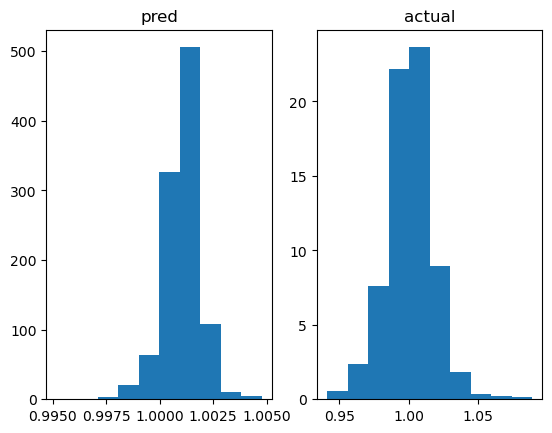

In [37]:
#GRU

#wczytuję ceny akcji
df = pd.read_csv("AAPL.csv")
close = np.array(df["Close"])


#wyznaczam zwroty logarytmiczne
returns = close[1:]/close[:-1]
log_returns = np.log(returns)

#wyznaczam kroczące volatility
rvolwin  = 10
windows = sliding_window_view(log_returns, window_shape=rvolwin)
rvol = windows.std(axis=1, ddof=1)

#odpowiedio skracam zwroty aby odpowiaday kroczącemu volatility
log_returns = log_returns[rvolwin-1:]

#sklejam zwroty i kroczące volatility
combined = np.vstack((rvol, 
              log_returns))

#wyznaczam parametry do standaryzacji danych 
rvol_sd = np.std(rvol)
rvol_mean = np.mean(rvol)

log_returns_sd = np.std(log_returns)
log_returns_mean = np.mean(log_returns)

#standaryzuje dane
combined[0,:] =  (combined[0,:] - rvol_mean)/rvol_sd
combined[1,:] =  (combined[1,:] - log_returns_mean)/log_returns_sd

#tworzę ciągi długości seq len, na ktorych będę uczył model
seq_len = 30

X = []
Y = []

for i in range(combined.shape[1] - seq_len):
    X.append(combined[:,i:(seq_len + i)])
    Y.append(combined[:,i + seq_len])

#formatuję dane 

X = torch.tensor(X).float()
Y = torch.tensor(Y).float()

X = X.reshape((X.shape[0],
               X.shape[2],
               X.shape[1]))

#dzielę na podzbiór uczący i testowy
test_size = 1000

test_X = X[X.shape[0]- test_size:, :, :]
test_Y = Y[Y.shape[0] - test_size:,]

train_X = X[:-test_size, :, :]
train_Y = Y[:-test_size,:]

class model(nn.Module):
    #inicjalizaja modelu
    def __init__(self, input_size=2, hidden_size=60, output_size=2):
        super().__init__()
        self.rnn = nn.GRU(input_size, hidden_size, batch_first=False, num_layers=2, dropout = 0.2)
        self.fc = nn.Linear(hidden_size, output_size)

    #propagacja w przód
    def forward(self, x):
        x = x.transpose(0, 1)
        out, _ = self.rnn(x)
        out = self.fc(out[-1]) 
        return out

#obiekty do wczytywania danych

train_dataset = TensorDataset(train_X, train_Y)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

test_dataset = TensorDataset(test_X, test_Y)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

#inijalizacja modelu
model = model()
#kryterium
criterion = nn.MSELoss()
#algorytm optymalizacji
optimizer = torch.optim.AdamW(model.parameters(), lr= 0.001, weight_decay= 0.0001)

#pętla ucząca
num_epochs = 10
for epoch in range(num_epochs):
    #trub uczący 
    model.train()
    for batch_x, batch_y in train_loader:
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        optimizer.zero_grad()
        loss.backward()
        #zapobiega eksplozji gradientu 
        optimizer.step()
    print(f"Epoch {epoch+1}/{num_epochs},Training Loss: {loss.item():.4f}")

#tryb predykcji 
model.eval()
test_loss = 0
#obliczanie błędu predykcji 
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        test_loss += criterion(outputs, batch_y).item()
test_loss /= len(test_loader)
print(f"Test Loss: {test_loss:.4f}")

pred = (model(test_X).T[1,:]*log_returns_sd + log_returns_mean).exp()
actual = np.exp(log_returns[len(log_returns) - test_size:])

print(f"Actual up: {sum(actual > 1)}, Predicted up: {sum(pred>1)}")

val = ((pd.DataFrame(actual > 1) == pd.DataFrame(pred > 1)).sum()/test_size)[0]
print(f"Accuracy: {val}")
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

plt.subplot(1, 2, 1)
plt.hist(pred.detach().numpy(), density = True)
plt.title("pred")
plt.subplot(1, 2, 2)
plt.hist(actual, density = True)
plt.title("actual")




Epoch 1/10,Training Loss: 0.1264
Epoch 2/10,Training Loss: 0.1172
Epoch 3/10,Training Loss: 0.1147
Epoch 4/10,Training Loss: 0.1169
Epoch 5/10,Training Loss: 0.1226
Epoch 6/10,Training Loss: 0.1172
Epoch 7/10,Training Loss: 0.1152
Epoch 8/10,Training Loss: 0.1168
Epoch 9/10,Training Loss: 0.1206
Epoch 10/10,Training Loss: 0.1266
Test Loss: 0.1900
Actual up: 526, Predicted up: 952
Accuracy: 0.516


Text(0.5, 1.0, 'actual')

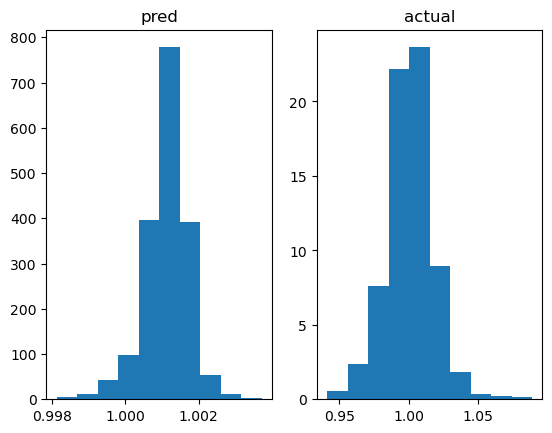

In [39]:
#LSTM

#wczytuję ceny akcji
df = pd.read_csv("AAPL.csv")
close = np.array(df["Close"])


#wyznaczam zwroty logarytmiczne
returns = close[1:]/close[:-1]
log_returns = np.log(returns)

#wyznaczam kroczące volatility
rvolwin  = 10
windows = sliding_window_view(log_returns, window_shape=rvolwin)
rvol = windows.std(axis=1, ddof=1)

#odpowiedio skracam zwroty aby odpowiaday kroczącemu volatility
log_returns = log_returns[rvolwin-1:]

#sklejam zwroty i kroczące volatility
combined = np.vstack((rvol, 
              log_returns))

#wyznaczam parametry do standaryzacji danych 
rvol_sd = np.std(rvol)
rvol_mean = np.mean(rvol)

log_returns_sd = np.std(log_returns)
log_returns_mean = np.mean(log_returns)

#standaryzuje dane
combined[0,:] =  (combined[0,:] - rvol_mean)/rvol_sd
combined[1,:] =  (combined[1,:] - log_returns_mean)/log_returns_sd

#tworzę ciągi długości seq len, na ktorych będę uczył model
seq_len = 20

X = []
Y = []

for i in range(combined.shape[1] - seq_len):
    X.append(combined[:,i:(seq_len + i)])
    Y.append(combined[:,i + seq_len])

#formatuję dane 

X = torch.tensor(X).float()
Y = torch.tensor(Y).float()

X = X.reshape((X.shape[0],
               X.shape[2],
               X.shape[1]))

#dzielę na podzbiór uczący i testowy
test_size = 1000

test_X = X[X.shape[0]- test_size:, :, :]
test_Y = Y[Y.shape[0] - test_size:,]

train_X = X[:-test_size, :, :]
train_Y = Y[:-test_size,:]

class model(nn.Module):
    #inicjalizaja modelu
    def __init__(self, input_size=2, hidden_size=60, output_size=2):
        super().__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, batch_first=False, num_layers=2, dropout = 0.2)
        self.fc = nn.Linear(hidden_size, output_size)

    #propagacja w przód
    def forward(self, x):
        x = x.transpose(0, 1)
        out, _ = self.rnn(x)
        out = self.fc(out[-1]) 
        return out

#obiekty do wczytywania danych

train_dataset = TensorDataset(train_X, train_Y)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

test_dataset = TensorDataset(test_X, test_Y)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

#inijalizacja modelu
model = model()
#kryterium
criterion = nn.MSELoss()
#algorytm optymalizacji
optimizer = torch.optim.Adam(model.parameters(), lr= 0.001)

#pętla ucząca
num_epochs = 10
for epoch in range(num_epochs):
    #trub uczący 
    model.train()
    for batch_x, batch_y in train_loader:
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        optimizer.zero_grad()
        loss.backward()
        #zapobiega eksplozji gradientu 
        optimizer.step()
    print(f"Epoch {epoch+1}/{num_epochs},Training Loss: {loss.item():.4f}")

#tryb predykcji 
model.eval()
test_loss = 0
#obliczanie błędu predykcji 
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        test_loss += criterion(outputs, batch_y).item()
test_loss /= len(test_loader)
print(f"Test Loss: {test_loss:.4f}")

pred = (model(test_X).T[1,:]*log_returns_sd + log_returns_mean).exp()
actual = np.exp(log_returns[len(log_returns) - test_size:])

print(f"Actual up: {sum(actual > 1)}, Predicted up: {sum(pred>1)}")

val = ((pd.DataFrame(actual > 1) == pd.DataFrame(pred > 1)).sum()/test_size)[0]
print(f"Accuracy: {val}")
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

plt.subplot(1, 2, 1)
plt.hist(pred.detach().numpy(), density = True)
plt.title("pred")
plt.subplot(1, 2, 2)
plt.hist(actual, density = True)
plt.title("actual")




Epoch 1/100, Train Loss: 0.9722, Val Loss: 0.8684
Epoch 2/100, Train Loss: 0.8891, Val Loss: 0.5107
Epoch 3/100, Train Loss: 0.7328, Val Loss: 0.4108
Epoch 4/100, Train Loss: 0.6699, Val Loss: 0.3929
Epoch 5/100, Train Loss: 0.6570, Val Loss: 0.3876
Epoch 6/100, Train Loss: 0.6481, Val Loss: 0.3858
Epoch 7/100, Train Loss: 0.6364, Val Loss: 0.3893
Epoch 8/100, Train Loss: 0.6300, Val Loss: 0.3901
Epoch 9/100, Train Loss: 0.6231, Val Loss: 0.3898
Epoch 10/100, Train Loss: 0.6178, Val Loss: 0.3840
Epoch 11/100, Train Loss: 0.6145, Val Loss: 0.3844
Epoch 12/100, Train Loss: 0.6116, Val Loss: 0.3828
Epoch 13/100, Train Loss: 0.6094, Val Loss: 0.3851
Epoch 14/100, Train Loss: 0.6108, Val Loss: 0.3881
Epoch 15/100, Train Loss: 0.6040, Val Loss: 0.3823
Epoch 16/100, Train Loss: 0.6001, Val Loss: 0.3821
Epoch 17/100, Train Loss: 0.5977, Val Loss: 0.3815
Epoch 18/100, Train Loss: 0.5987, Val Loss: 0.3836
Epoch 19/100, Train Loss: 0.5945, Val Loss: 0.3795
Epoch 20/100, Train Loss: 0.5973, Val Lo

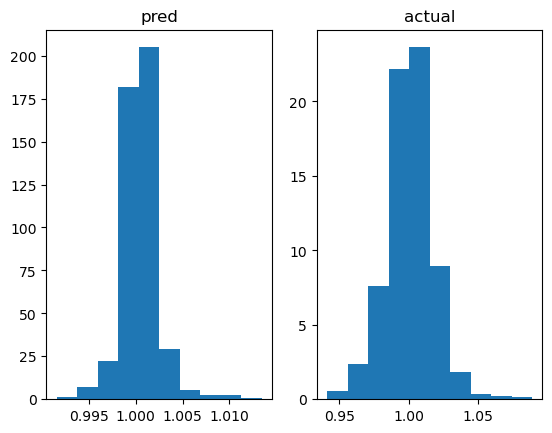

In [42]:
import numpy as np
import pandas as pd
from numpy.lib.stride_tricks import sliding_window_view
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.utils
import torch.optim.lr_scheduler
import matplotlib.pyplot as plt
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# wczytuję ceny akcji
df = pd.read_csv("AAPL.csv")
close = np.array(df["Close"])

# wyznaczam zwroty logarytmiczne
returns = close[1:]/close[:-1]
log_returns = np.log(returns)

# wyznaczam kroczące volatility
rvolwin  = 10
windows = sliding_window_view(log_returns, window_shape=rvolwin)
rvol = windows.std(axis=1, ddof=1)

# odpowiednio skracam zwroty aby odpowiadały kroczącemu volatility
log_returns = log_returns[rvolwin-1:]

# sklejam zwroty i kroczące volatility
combined = np.vstack((rvol, 
              log_returns))

# wyznaczam parametry do standaryzacji danych 
rvol_sd = np.std(rvol)
rvol_mean = np.mean(rvol)

log_returns_sd = np.std(log_returns)
log_returns_mean = np.mean(log_returns)

# standaryzuje dane
combined[0,:] =  (combined[0,:] - rvol_mean)/rvol_sd
combined[1,:] =  (combined[1,:] - log_returns_mean)/log_returns_sd

# tworzę ciągi długości seq len, na których będę uczył model
seq_len = 20

X = []
Y = []

for i in range(combined.shape[1] - seq_len):
    X.append(combined[:,i:(seq_len + i)])
    Y.append(combined[:,i + seq_len])

# formatuję dane 
X = torch.tensor(X).float()
Y = torch.tensor(Y).float()

X = X.reshape((X.shape[0],
               X.shape[2],
               X.shape[1]))

# dzielę na podzbiór uczący i testowy
test_size = 1000

test_X = X[X.shape[0]- test_size:, :, :]
test_Y = Y[Y.shape[0] - test_size:,]

train_X = X[:-test_size, :, :]
train_Y = Y[:-test_size,:]

# dodajemy walidację (ostatnie 500 próbek z train)
val_size = 500
if len(train_X) > val_size:
    val_X = train_X[-val_size:, :, :]
    val_Y = train_Y[-val_size:, :]
    train_X = train_X[:-val_size, :, :]
    train_Y = train_Y[:-val_size, :]
else:
    val_X = train_X
    val_Y = train_Y
    train_X = train_X  # bez zmian jeśli za mało

# obiekty do wczytywania danych
train_dataset = TensorDataset(train_X, train_Y)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

val_dataset = TensorDataset(val_X, val_Y)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

test_dataset = TensorDataset(test_X, test_Y)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class model(nn.Module):
    # inicjalizacja modelu
    def __init__(self, input_size=2, hidden_size=60, output_size=2):
        super().__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, batch_first=False, num_layers=2, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)

    # propagacja w przód
    def forward(self, x):
        x = x.transpose(0, 1)
        out, _ = self.rnn(x)
        out = self.fc(out[-1]) 
        return out

# inicjalizacja modelu
model = model()
# kryterium
criterion = nn.MSELoss()
# algorytm optymalizacji (AdamW + weight decay)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
# scheduler (usunięto 'verbose=True', ponieważ nie jest wspierane w PyTorch 2.7+)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

# early stopping
best_val_loss = float('inf')
patience = 10
patience_counter = 0

# pętla ucząca
num_epochs = 100
for epoch in range(num_epochs):
    # tryb uczący 
    model.train()
    train_loss = 0.0
    for batch_x, batch_y in train_loader:
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        optimizer.zero_grad()
        loss.backward()
        # gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    
    # walidacja
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            outputs = model(batch_x)
            val_loss += criterion(outputs, batch_y).item()
    val_loss /= len(val_loader)
    
    scheduler.step(val_loss)
    
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
    # early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# tryb predykcji 
model.eval()
test_loss = 0
# obliczanie błędu predykcji 
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        test_loss += criterion(outputs, batch_y).item()
test_loss /= len(test_loader)
print(f"Test Loss: {test_loss:.4f}")

pred = (model(test_X).T[1,:]*log_returns_sd + log_returns_mean).exp()
actual = np.exp(log_returns[len(log_returns) - test_size:])

print(f"Actual up: {sum(actual > 1)}, Predicted up: {sum(pred>1)}")

val = ((pd.DataFrame(actual > 1) == pd.DataFrame(pred > 1)).sum()/test_size)[0]
print(f"Accuracy: {val}")

plt.subplot(1, 2, 1)
plt.hist(pred.detach().numpy(), density = True)
plt.title("pred")
plt.subplot(1, 2, 2)
plt.hist(actual, density = True)
plt.title("actual")
plt.show()